In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1,1)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (150, 4)
Output shape: (150, 1)


In [3]:
encoder = OneHotEncoder(sparse_output=False)

y = encoder.fit_transform(y)


scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

print(X_train.shape)
print(y_train.shape)

(120, 4)
(120, 3)


In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-x))


def sigmoid_derivative(x):
    return x*(1-x)

In [6]:
input_neurons = 4
hidden_neurons = 5
output_neurons = 3


np.random.seed(42)


W1 = np.random.randn(input_neurons, hidden_neurons)

b1 = np.zeros((1,hidden_neurons))


W2 = np.random.randn(hidden_neurons, output_neurons)

b2 = np.zeros((1,output_neurons))


learning_rate = 0.1
epochs = 10000

In [7]:
losses=[]


for i in range(epochs):

    # -------- Forward Propagation --------

    z1 = np.dot(X_train,W1)+b1

    a1 = sigmoid(z1)


    z2 = np.dot(a1,W2)+b2

    output = sigmoid(z2)



    # -------- Error --------

    error = y_train - output


    loss = np.mean(error**2)

    losses.append(loss)



    # -------- Backpropagation --------


    d_output = error * sigmoid_derivative(output)


    d_W2 = np.dot(a1.T,d_output)


    d_b2 = np.sum(d_output,axis=0,keepdims=True)



    d_hidden = np.dot(d_output,W2.T) * sigmoid_derivative(a1)


    d_W1 = np.dot(X_train.T,d_hidden)


    d_b1 = np.sum(d_hidden,axis=0,keepdims=True)



    # -------- Update Weights --------

    W2 += learning_rate*d_W2

    b2 += learning_rate*d_b2


    W1 += learning_rate*d_W1

    b1 += learning_rate*d_b1



print("Training Completed")

Training Completed


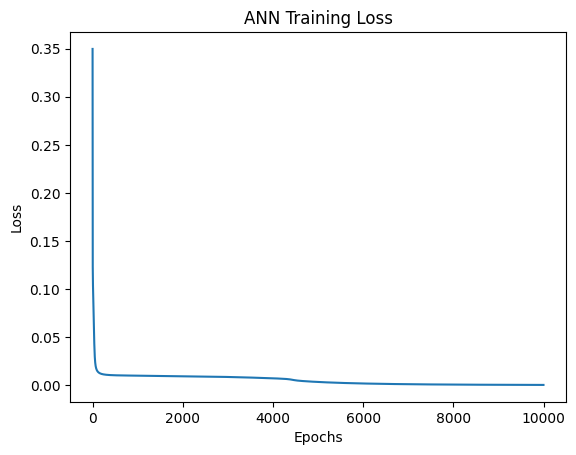

In [8]:
plt.plot(losses)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("ANN Training Loss")

plt.show()

In [9]:
z1 = np.dot(X_test,W1)+b1

a1 = sigmoid(z1)


z2 = np.dot(a1,W2)+b2

prediction = sigmoid(z2)


predicted_class = np.argmax(prediction,axis=1)

actual_class = np.argmax(y_test,axis=1)


accuracy = accuracy_score(
    actual_class,
    predicted_class
)


print("Accuracy =",accuracy*100,"%")

Accuracy = 93.33333333333333 %


In [10]:
cm = confusion_matrix(
    actual_class,
    predicted_class
)

print(cm)

[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]
